In [1]:
from sklearn.datasets import fetch_openml
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeRegressor 
from sklearn.metrics import r2_score, explained_variance_score, confusion_matrix, accuracy_score, classification_report, mean_absolute_error
import seaborn as sns

In [2]:
mnist = fetch_openml('mnist_784')

In [3]:
x, y = mnist['data'], mnist['target']

In [4]:
x = np.array(x)
y = np.array(y)

In [5]:
x.shape

(70000, 784)

In [6]:
y = y.astype('int')

In [7]:
x_train, x_test = x[:60000], x[60000:70000]
y_train, y_test = y[:60000], y[60000:70000]

In [8]:
x_train.shape

(60000, 784)

In [9]:
x_test.shape

(10000, 784)

In [10]:
y_train.shape



(60000,)

In [11]:
y_test.shape

(10000,)

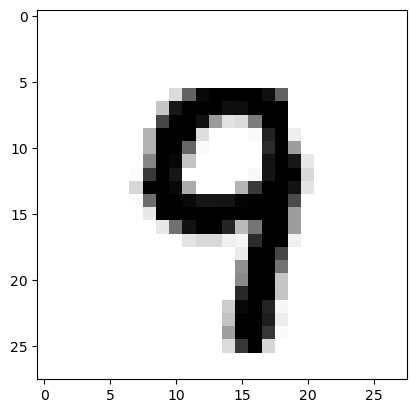

In [12]:
some_image = x[520]
some_image = some_image.reshape(28,28)
plt.imshow(some_image, cmap=matplotlib.cm.binary,interpolation='nearest')

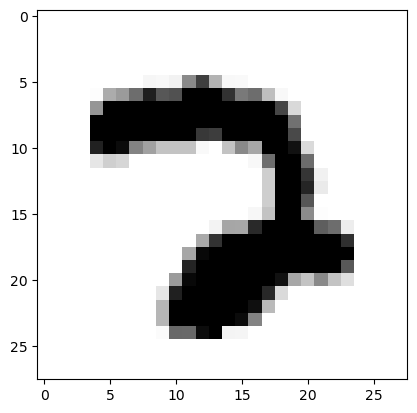

In [13]:
some_image = x[120]
some_image = some_image.reshape(28,28)
plt.imshow(some_image, cmap=matplotlib.cm.binary,interpolation='nearest')

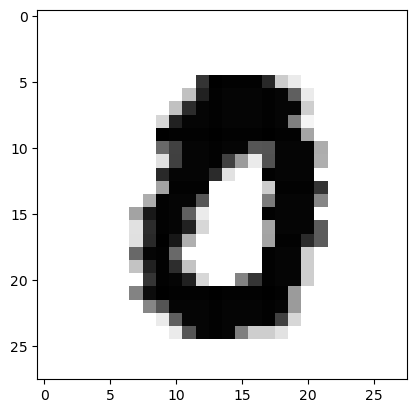

In [15]:
some_image = x[69]
some_image = some_image.reshape(28,28)
plt.imshow(some_image, cmap=matplotlib.cm.binary,interpolation='nearest')

In [16]:

lr = 0.1 

In [17]:
dt = DecisionTreeRegressor(max_depth = 1)
dt.fit(x_train,y_train)

DecisionTreeRegressor(max_depth=1)

In [18]:
y_pred = dt.predict(x_test)

In [19]:
y_pred[:10]
     

array([5.36713732, 2.6254691 , 2.6254691 , 2.6254691 , 5.36713732,
       2.6254691 , 5.36713732, 5.36713732, 2.6254691 , 5.36713732])

In [20]:
mae = mean_absolute_error(y_test,  y_pred)
mae

2.2267110373114707

In [21]:
score = r2_score(y_test, y_pred)
score

0.22100481734722865

In [22]:

y_pred = np.round(y_pred)

In [23]:

print(accuracy_score( y_test, y_pred))  




0.0716


In [24]:

y_it1 = dt.predict(x_train)
y_it1 = np.round(y_it1)

In [25]:
y_train1 = y_train - y_it1

In [26]:

dt1 = DecisionTreeRegressor(max_depth = 1)
dt1.fit(x_train,  y_train1)

DecisionTreeRegressor(max_depth=1)

In [27]:
y_pred1 = dt1.predict(x_test)
y_pred1 = np.round(y_pred1)
print(accuracy_score( y_test, y_pred + y_pred1 ))

0.1238


In [28]:

y_it2 = dt1.predict(x_train)
y_it2 = np.round(y_it2)

In [29]:
y_train2 = y_train1 - y_it2

In [30]:
dt2 = DecisionTreeRegressor(max_depth = 1)
dt2.fit(x_train,  y_train2)

DecisionTreeRegressor(max_depth=1)

In [31]:

y_pred2 = dt2.predict(x_test)
y_pred2 = np.round(y_pred2) 
print(accuracy_score( y_test, y_pred + y_pred1 + y_pred2 )) 

0.1371


In [32]:

y_it3 = dt2.predict(x_train)
y_it3 = np.round(y_it3)

In [33]:
y_train3 =  y_train2 - y_it3

In [34]:

dt3 = DecisionTreeRegressor(max_depth = 1)
dt3.fit( x_train,  y_train3 )

DecisionTreeRegressor(max_depth=1)

In [35]:

y_pred3 = dt3.predict(x_test)
y_pred3 = np.round(y_pred3) 
print(accuracy_score( y_test, y_pred + y_pred1 + y_pred2 + y_pred3 )) 

0.1934


In [36]:

y_it4 = dt3.predict(x_train)
y_it4 = np.round(y_it4)

In [37]:
y_train4 =  y_train3 - y_it4

In [38]:
dt4 = DecisionTreeRegressor(max_depth = 1)
dt4.fit( x_train,  y_train4 )

DecisionTreeRegressor(max_depth=1)

In [39]:

y_pred4 = dt4.predict(x_test)
y_pred4 = np.round(y_pred4) 
print(accuracy_score( y_test, y_pred + y_pred1 + y_pred2 + y_pred3 + y_pred4))  

0.1447
